# Word Embeddings — Notebook 1 (Clase 4)

**De token a vector: cómo el texto pasa a vivir en un espacio donde el significado es geometría.**

Este notebook acompaña al deck de la Clase 4. Venimos construyendo las partes de un LLM —en la Clase 2 armamos un Transformer desde cero, en la Clase 3 la tokenización—. Los **embeddings** son la capa que convierte cada token en un vector, y son la primera pieza del modelo.

Pero acá hacemos un **paréntesis deliberado**. En vez de mirar la tabla de embeddings *adentro* del LLM, la estudiamos sola: cómo se construye un espacio de vectores donde palabras parecidas quedan cerca. Ese paradigma —un modelo de embeddings entrenado por su cuenta— es también el motor de **RAG** (Unidad 4). Así, esta clase sostiene las dos puntas: explica por qué la capa de abajo de un LLM es una *lookup table*, y planta el mecanismo que RAG va a dar por sentado.

El recorrido: primero la regla para medir parecido (**similitud coseno**); después el arco de cómo llenar la tabla de embeddings con significado (**one-hot → contar (co-ocurrencia + SVD) → predecir (word2vec) → GloVe**); y cerramos con la bisagra hacia los embeddings *contextuales* que ya construyeron. El Notebook 2 sigue con *sentence embeddings* y búsqueda semántica.

## Sección 0 — Setup

Todo lo que el notebook necesita para correr de arriba a abajo. El stack es libre y open-source (gensim, scikit-learn, PyTorch); corre en **CPU**, no hace falta GPU.

> **Ojo (Colab).** Si `import gensim` tira un error de `scipy` (algo como `cannot import name 'triu'`), es un choque conocido de versiones: corré la celda de instalación, hacé **Runtime → Restart session** y volvé a correr desde acá. gensim ≥ 4.3.3 ya lo tiene resuelto.

In [1]:
# Instalamos todo lo necesario (libre y open-source). -q = silencioso.
!pip -q install --upgrade gensim nltk scikit-learn matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 53.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 57.2 MB/s eta 0:00:00


In [2]:
import numpy as np
import torch
import torch.nn as nn
from torch.nn import functional as F

import gensim
import gensim.downloader as api          # para bajar text8 y GloVe pre-entrenados
from gensim.models import Word2Vec       # para entrenar word2vec

# Parche de compatibilidad: gensim-data espera el nombre viejo `smart_open.smart_open`,
# que smart_open >= 2.0 movió a smart_open.open. Debe ir antes de cualquier api.load.
import smart_open
if not hasattr(smart_open, "smart_open"):
    smart_open.smart_open = smart_open.open

import json                              # para imprimir dicts de forma legible
from collections import Counter          # para contar frecuencias de palabras
from sklearn.decomposition import TruncatedSVD   # para comprimir la matriz de co-ocurrencia
import matplotlib.pyplot as plt

# Semilla fija para que los resultados impresos sean reproducibles (misma convención que la Clase 2).
SEED = 1337
np.random.seed(SEED)
torch.manual_seed(SEED)

print("numpy  ", np.__version__)
print("torch  ", torch.__version__)
print("gensim ", gensim.__version__)

numpy   2.1.3
torch   2.11.0+cpu
gensim  4.4.0


In [3]:
# Datos de NLTK (en su propia celda, con opt-in defensivo para entornos con proxy).
import nltk
try:
    import nltk.pathsec
    nltk.pathsec.ALLOW_PROXIED_FETCH = True   # sólo hace falta si hay un proxy de por medio; inofensivo si no
except (ImportError, AttributeError):
    pass                                       # NLTK viejo: no existe pathsec, no hay nada que habilitar

nltk.download('reuters')
from nltk.corpus import reuters
print("reuters OK ->", len(reuters.fileids()), "documentos")

[nltk_data] Downloading package reuters to /root/nltk_data...


reuters OK -> 10788 documentos


## 1 — Similitud coseno

Todo lo que viene —comparar palabras, buscar las más parecidas, armar búsqueda semántica— necesita una regla que tome dos vectores y devuelva **un número** de "cuánto se parecen". La que usamos en toda la clase es el **coseno del ángulo** entre los dos vectores. La presentamos primero, sola, porque es la herramienta con la que vamos a medir todo lo demás.

La fórmula es el producto punto normalizado por las magnitudes:

`cos(a, b) = (a · b) / (||a|| · ||b||)`

Cada parte tiene un rol: el **producto punto** `a · b` crece cuando los vectores apuntan parecido, y dividir por las **normas** `||a||·||b||` cancela el largo de cada uno, dejando pura **orientación**.

**Cómo se lee la similitud coseno** (`cos`), atado al ángulo:
- **cos = 1** → ángulo **0°**, apuntan en la **misma dirección**: máximo parecido.
- **cos = 0** → ángulo **90°**, son **ortogonales**: no tienen nada en común.
- **cos = −1** → ángulo **180°**, direcciones **opuestas**.

**La distancia coseno.** En búsqueda uno no piensa en "qué tan parecido" sino en "qué tan **lejos**": quiere el vector *más cercano*. Para eso se da vuelta la similitud y se define la **distancia coseno**:

`dist(a, b) = 1 − cos(a, b)`

Es la imagen espejo de la similitud, y se lee como una distancia (más chica = más cerca):
- **dist = 0** → vectores en la misma dirección: **distancia mínima**, lo más cercano posible.
- **dist = 1** → ortogonales: sin relación.
- **dist = 2** → opuestos: **lo más lejos** que se puede.

Son la misma información en dos envases: `most_similar` (buscar el coseno más **alto**) equivale a buscar la distancia coseno más **baja**. Las dos conviven porque las librerías de embeddings las usan indistintamente — gensim devuelve *similitud*; un vector store como FAISS suele rankear por *distancia*.

> **Ojo, un detalle que confunde.** `cos = 0` **no** es "distancia 0": ortogonal es `cos = 0` **y** `dist = 1`. La distancia 0 corresponde a `cos = 1` (idénticos en dirección). Similitud alta ↔ distancia baja, no son el mismo número.

Una propiedad clave: el coseno compara **dirección, no tamaño**. Un vector que apunta igual que otro pero es el doble de largo da `cos = 1` igual. (Por qué usamos justo el coseno y no la distancia euclidiana lo vemos en la Sección 5; por ahora alcanza con "coseno alto / distancia baja = parecido".)

Veámoslo con números y un dibujo.

a = [2 1]   |a| = 2.236

vector         a · v     |v|  cos(a,v)  ángulo  dist(a,v)
b = [4, 2]     10.00   4.472     1.000   0.0°       0.000
e = [1, 3]      5.00   3.162     0.707  45.0°       0.293
c = [-1, 2]     0.00   2.236     0.000  90.0°       1.000
d = [-2, -1]   -5.00   2.236    -1.000 180.0°       2.000


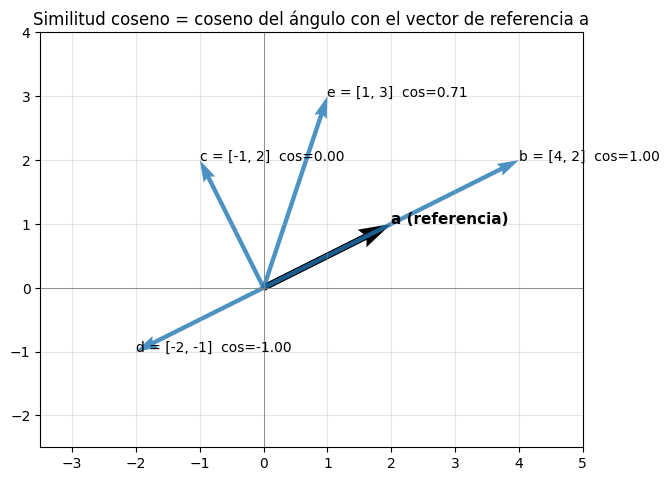

In [4]:
# cosine(a, b): producto punto / (norma de a * norma de b) = coseno del ángulo entre a y b.
def cosine(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# cosine_distance(a, b): la imagen espejo, 1 - coseno (0 = misma dirección, 2 = opuestos).
def cosine_distance(a, b):
    return 1 - cosine(a, b)

# Vectores 2D de juguete (para poder verlos y medir el ángulo a ojo).
a = np.array([2, 1])          # vector de referencia
vectores = {
    "b = [4, 2]":   np.array([4, 2]),    # misma dirección que a, el doble de largo
    "e = [1, 3]":   np.array([1, 3]),    # dirección parecida, no igual
    "c = [-1, 2]":  np.array([-1, 2]),   # perpendicular a a
    "d = [-2, -1]": np.array([-2, -1]),  # dirección opuesta a a
}

# --- Los números, paso a paso (ver, no postular) ---
# Para cada vector: producto punto con a, su norma, el coseno, el ángulo (arccos del coseno) y la distancia.
print(f"a = {a}   |a| = {np.linalg.norm(a):.3f}\n")
print(f"{'vector':12s} {'a · v':>7s} {'|v|':>7s} {'cos(a,v)':>9s} {'ángulo':>7s} {'dist(a,v)':>10s}")
for name, v in vectores.items():
    dot = float(np.dot(a, v))
    cs  = cosine(a, v)
    ang = np.degrees(np.arccos(np.clip(cs, -1, 1)))   # el ángulo cuyo coseno es cs (clip evita errores de redondeo)
    print(f"{name:12s} {dot:7.2f} {np.linalg.norm(v):7.3f} {cs:9.3f} {ang:5.1f}°  {cosine_distance(a, v):10.3f}")

# --- El dibujo: cada vector como una flecha desde el origen ---
plt.figure(figsize=(7, 7))
plt.axhline(0, color="gray", lw=0.6); plt.axvline(0, color="gray", lw=0.6)   # ejes

# quiver dibuja una flecha; angles/scale_units/scale=1 la dibujan a escala real (1:1).
plt.quiver(0, 0, a[0], a[1], angles="xy", scale_units="xy", scale=1, color="black", width=0.012)
plt.annotate("a (referencia)", (a[0], a[1]), fontsize=11, fontweight="bold")

for name, v in vectores.items():
    plt.quiver(0, 0, v[0], v[1], angles="xy", scale_units="xy", scale=1, color="tab:blue", width=0.008, alpha=0.8)
    plt.annotate(f"{name}  cos={cosine(a, v):.2f}", (v[0], v[1]), fontsize=10)

plt.xlim(-3.5, 5); plt.ylim(-2.5, 4)
plt.gca().set_aspect("equal")   # misma escala en x e y, para que los ángulos se vean reales
plt.title("Similitud coseno = coseno del ángulo con el vector de referencia a")
plt.grid(True, alpha=0.3)
plt.show()

**Lo que se ve.** El coseno es, literalmente, el coseno del ángulo: `b` apunta igual que `a` (0°, cos 1) aunque sea el doble de largo — dirección, no tamaño; `e` está a 45° (cos 0.71); `c` es perpendicular (90°, cos 0); `d` apunta al revés (180°, cos −1). Y la distancia acompaña en espejo: 0 para el que apunta igual, 2 para el opuesto.

Ya tenemos la regla para medir parecido. Apliquémosla primero al candidato más ingenuo de vector para una palabra: el **one-hot**.

## 2 — De one-hot a lookup table

Ya tenemos texto → token IDs (eso fue la Clase 3). Para meter un token en una red necesitamos un **vector**. El candidato ingenuo es **one-hot**.

**La idea clave.** Con un vocabulario de tamaño `V`, cada token es un vector de `V` ceros con un único `1` en la posición de su ID. Es una representación de *identidad*: dice *cuál* token es, y nada más.

Tiene dos problemas. Uno es el tamaño: `V` puede ser 50.000 y el vector es casi todo ceros (*sparse*). El otro es el que importa, y ahora que tenemos el coseno lo podemos ver medido.

In [5]:
# Un vocabulario de juguete para ver el problema de cerca. (Reusamos `cosine` de la Sección 1.)
vocab = ["gato", "perro", "avión", "auto", "democracia"]
V = len(vocab)                                # tamaño del vocabulario
stoi = {w: i for i, w in enumerate(vocab)}    # string-to-index: palabra -> id (mismo patrón que en tokenización)
print("vocab:", vocab)
print("V:", V)
print("stoi:", stoi)

# one_hot_np(idx, size): vector de `size` ceros con un 1 en la posición idx.
def one_hot_np(idx, size):
    v = np.zeros(size)     # (V,)  -> todo ceros...
    v[idx] = 1.0           #        ...menos un 1 en la posición del token
    return v

gato  = one_hot_np(stoi["gato"],  V)
perro = one_hot_np(stoi["perro"], V)
avion = one_hot_np(stoi["avión"], V)

print("\none-hot de 'gato':", gato, " shape:", gato.shape)
print()
# cosine entre one-hots: como no comparten posiciones encendidas, siempre da 0.
print("cosine(gato, perro) =", cosine(gato, perro))
print("cosine(gato, avión) =", cosine(gato, avion))

vocab: ['gato', 'perro', 'avión', 'auto', 'democracia']
V: 5
stoi: {'gato': 0, 'perro': 1, 'avión': 2, 'auto': 3, 'democracia': 4}

one-hot de 'gato': [1. 0. 0. 0. 0.]  shape: (5,)

cosine(gato, perro) = 0.0
cosine(gato, avión) = 0.0


**Lo que hay que ver.** `gato` es *tan* parecido a `perro` como a `avión`: en los dos casos el coseno da **0**. Cualquier one-hot es ortogonal a cualquier otro, porque no comparten ninguna posición encendida. One-hot codifica identidad y **cero significado**. Queremos lo contrario: vectores densos, de baja dimensión, donde `cosine(gato, perro)` sea alto y `cosine(gato, avión)` bajo.

### La identidad clave: un embedding es `one_hot(x) @ C`

Antes de aprender significado, entendamos la *mecánica*. Un **embedding** es una tabla `C` de forma `(V, d)`: `V` filas (una por token), cada una un vector de largo `d`. "Embeber" el token `i` es leer la fila `i` de `C`.

**La conexión con lo que ya construyeron.** En el Notebook 1 de la Clase 2 (Simple Bigram), `nn.Embedding` aparecía con `embedding_dim = vocab_size` y era un uso *atípico*: la fila se leía como los logits en crudo. Ahí anticipamos que "en el próximo milestone `C = n_embd` va a ser un embedding **de verdad** —un vector aprendido, no los logits". Esto es ese embedding de verdad, ahora en el centro de la escena.

Y hay una identidad que vale la pena ver con los ojos: **leer la fila `i` es exactamente lo mismo que multiplicar el one-hot de `i` por la tabla**.

```
one_hot(i) @ C  ==  C[i]
```

Tiene sentido: el one-hot tiene un solo `1` en la posición `i`, así que el producto matricial "selecciona" esa fila y descarta el resto. El *lookup* no es más que un one-hot multiplicando la tabla — sólo que hecho de forma eficiente, sin construir el one-hot gigante.

In [6]:
# Una tabla de embeddings de juguete: V filas, d=4 columnas. Arranca random (todavía no significa nada).
d = 4
C = nn.Embedding(V, d)          # nn.Embedding(num_embeddings, embedding_dim) = tabla (V, d); el mismo de la Clase 2

# Miremos la tabla: una fila por palabra del vocabulario, cada fila un vector de largo d.
tabla = C.weight.detach().numpy()   # .weight es la tabla; .detach().numpy() para poder imprimirla
print(f"Tabla de embeddings C  ->  shape {tuple(C.weight.shape)}  (V={V} filas, d={d} columnas)\n")
for w, fila in zip(vocab, tabla):
    print(f"  fila {stoi[w]}  {w:11s} {np.round(fila, 3)}")

# Elegimos un token: su índice y su one-hot.
idx = stoi["gato"]
oh = F.one_hot(torch.tensor(idx), num_classes=V).float()         # (V,)  one-hot en versión torch
print(f"\ntoken: 'gato'   ->   idx: {idx}")
print(f"one-hot 'oh'    ->   shape {tuple(oh.shape)} :  {oh.numpy()}")
print(f"                     el único 1 está en la posición {idx}, así que selecciona la fila {idx} de C")

# Camino 1: el lookup (lo que hace nn.Embedding por dentro) = leer la fila idx.
via_lookup = C(torch.tensor(idx))                                # (d,)
# Camino 2: oh @ C, hecho a mano = el 1 de oh selecciona esa misma fila.
via_matmul = oh @ C.weight                                       # (V,) @ (V, d) -> (d,)

print(f"\nCamino 1  ->  lookup   C[{idx}]   : {via_lookup.detach().numpy().round(3)}")
print(f"Camino 2  ->  oh @ C             : {via_matmul.detach().numpy().round(3)}")
# allclose: True si los dos vectores son iguales (salvo redondeo mínimo).
print(f"\n¿son iguales? -> {torch.allclose(via_lookup, via_matmul)}   # CHECKPOINT: el lookup ES un one-hot por la tabla")

Tabla de embeddings C  ->  shape (5, 4)  (V=5 filas, d=4 columnas)

  fila 0  gato        [ 0.181 -0.07  -0.36  -0.915]
  fila 1  perro       [-2.037  0.493  1.487  0.591]
  fila 2  avión       [-0.048 -1.1   -1.752 -1.097]
  fila 3  auto        [ 0.448 -0.802  1.524  2.509]
  fila 4  democracia  [ 0.166  1.205  0.188 -2.16 ]

token: 'gato'   ->   idx: 0
one-hot 'oh'    ->   shape (5,) :  [1. 0. 0. 0. 0.]
                     el único 1 está en la posición 0, así que selecciona la fila 0 de C

Camino 1  ->  lookup   C[0]   : [ 0.181 -0.07  -0.36  -0.915]
Camino 2  ->  oh @ C             : [ 0.181 -0.07  -0.36  -0.915]

¿son iguales? -> True   # CHECKPOINT: el lookup ES un one-hot por la tabla


**Sanity check.** `torch.allclose(...) → True`: el lookup y el `one_hot @ C` dan el mismo vector. Un embedding es, mecánicamente, **una fila de una tabla**.

Pero fijate que esta `C` es *random*: sus vectores no significan nada. `one-hot` era el caso degenerado; `C` random es una tabla cualquiera, también sin significado. La pregunta que ocupa el resto del notebook es una sola: **¿cómo llenamos esa tabla para que la geometría refleje el significado?** Hay dos caminos —*contar* y *predecir*— y los recorremos en ese orden.

## 3 — Contar: co-ocurrencia + SVD desde cero

La primera idea para llenar la tabla con significado es vieja y poderosa: la **hipótesis distribucional** (Firth, 1957): *"una palabra se conoce por la compañía que mantiene"*. Palabras que aparecen en contextos parecidos tienen significados parecidos.

**El plan.** Contamos, para cada par de palabras, cuántas veces aparecen cerca (dentro de una ventana) en un corpus. Eso nos da una **matriz de co-ocurrencia**: la fila de una palabra es su "huella" de contextos. Palabras que comparten contextos tendrán filas parecidas.

Lo construimos desde cero con numpy, sobre un corpus chico (un subconjunto del Reuters).

In [7]:
# ---- Cargar el corpus ----
# reuters.fileids(cats): el corpus Reuters está etiquetado por tema; devuelve los IDs
#   de los documentos de esas categorías (un id es un string tipo 'training/9865').
# reuters.words(f): devuelve el documento f ya tokenizado en palabras (una lista).
# w.lower(): a minúsculas, para que 'Oil'/'OIL'/'oil' cuenten como la misma palabra.
# -> corpus queda como lista de documentos, y cada documento es una lista de palabras.
def read_corpus(categories):
    files = reuters.fileids(categories)
    return [[w.lower() for w in reuters.words(f)] for f in files]

# crude = petróleo, grain = granos: dos temas bien separados, para que se vean dos clusters.
corpus = read_corpus(["crude", "grain"])

# Lo miramos por dentro: los primeros 10 docs (primeras 10 palabras de cada uno).
for i, doc in enumerate(corpus[:10]):
    print(f"doc {i}: {doc[:10]}")
print("\ndocumentos:", len(corpus))

# ---- Construir el vocabulario ----
# Counter(generador): cuenta apariciones de cada palabra en TODO el corpus
#   (el generador recorre todas las palabras de todos los docs) -> {palabra: cuenta}.
freq = Counter(w for doc in corpus for w in doc)

# most_common(N): las N palabras más frecuentes como (palabra, cuenta); nos quedamos
#   sólo con la palabra. Recortamos a 1500 porque la matriz será Vc x Vc (crece al
#   cuadrado del vocabulario), y las frecuentes son las que tienen conteos útiles.
VOCAB_N = 1500
words = [w for w, _ in freq.most_common(VOCAB_N)]

# w2i (word-to-index): mapa palabra -> número de fila/columna (mismo patrón que stoi).
w2i = {w: i for i, w in enumerate(words)}
Vc = len(words)
print("\ntamaño de vocabulario (Vc):", Vc)

# Miramos cada objeto por dentro (los primeros 20) para entender qué quedó en cada uno.
print("\nfreq — 20 palabras más frecuentes (palabra: cuenta):")
print(json.dumps(dict(freq.most_common(20)), indent=2))
print("\nwords — las primeras 20 (sólo la palabra, ya sin la cuenta):")
print(words[:20])
print("\nw2i — los primeros 20 (palabra -> índice):")
print(json.dumps(dict(list(w2i.items())[:20]), indent=2))

# ---- Matriz de co-ocurrencia ----
# window = radio de contexto: son "vecinas" las 4 palabras a cada lado de la central.
# M[i, j] contará cuántas veces la palabra j cayó en la ventana de la palabra i
#   -> cada fila es la "huella de contextos" de una palabra.
window = 4
M = np.zeros((Vc, Vc), dtype=np.float32)      # (Vc, Vc), arranca en ceros

for doc in corpus:                             # la co-ocurrencia se cuenta dentro de cada doc
    # pasamos el doc a IDs y descartamos las palabras fuera del vocab (if w in w2i).
    ids = [w2i[w] for w in doc if w in w2i]
    for center_pos, c in enumerate(ids):       # cada palabra hace de central por turno
        lo = max(0, center_pos - window)                # borde izquierdo (sin pasarse del inicio)
        hi = min(len(ids), center_pos + window + 1)     # borde derecho (+1: range excluye el tope)
        for ctx_pos in range(lo, hi):          # recorremos la ventana
            if ctx_pos != center_pos:          # sin contar la palabra consigo misma
                M[c, ids[ctx_pos]] += 1.0      # +1 en [central, contexto]

print("\nmatriz de co-ocurrencia M:", M.shape)
print("muestra de M (primeras 5x5 celdas):\n", M[:5, :5])

doc 0: ['china', 'daily', 'says', 'vermin', 'eat', '7', '-', '12', 'pct', 'grain']
doc 1: ['japan', 'to', 'revise', 'long', '-', 'term', 'energy', 'demand', 'downwards', 'the']
doc 2: ['thai', 'trade', 'deficit', 'widens', 'in', 'first', 'quarter', 'thailand', "'", 's']
doc 3: ['sri', 'lanka', 'gets', 'usda', 'approval', 'for', 'wheat', 'price', 'food', 'department']
doc 4: ['japan', 'ministry', 'says', 'open', 'farm', 'trade', 'would', 'hit', 'u', '.']
doc 5: ['zambia', 'does', 'not', 'plan', 'retail', 'maize', 'price', 'hike', 'the', 'zambian']
doc 6: ['further', 'argentine', 'coarse', 'grain', 'losses', 'feared', 'argentine', 'grain', 'producers', 'adjusted']
doc 7: ['energy', '/', 'u', '.', 's', '.', 'petrochemical', 'industry', 'cheap', 'oil']
doc 8: ['honduras', 'seeking', 'pl', '-', '480', 'bulk', 'wheat', 'april', '13', 'honduras']
doc 9: ['brazil', 'grain', 'harvest', 'faces', 'storage', 'problems', 'storage', 'problems', 'with', 'brazil']

documentos: 1158

tamaño de vocabula

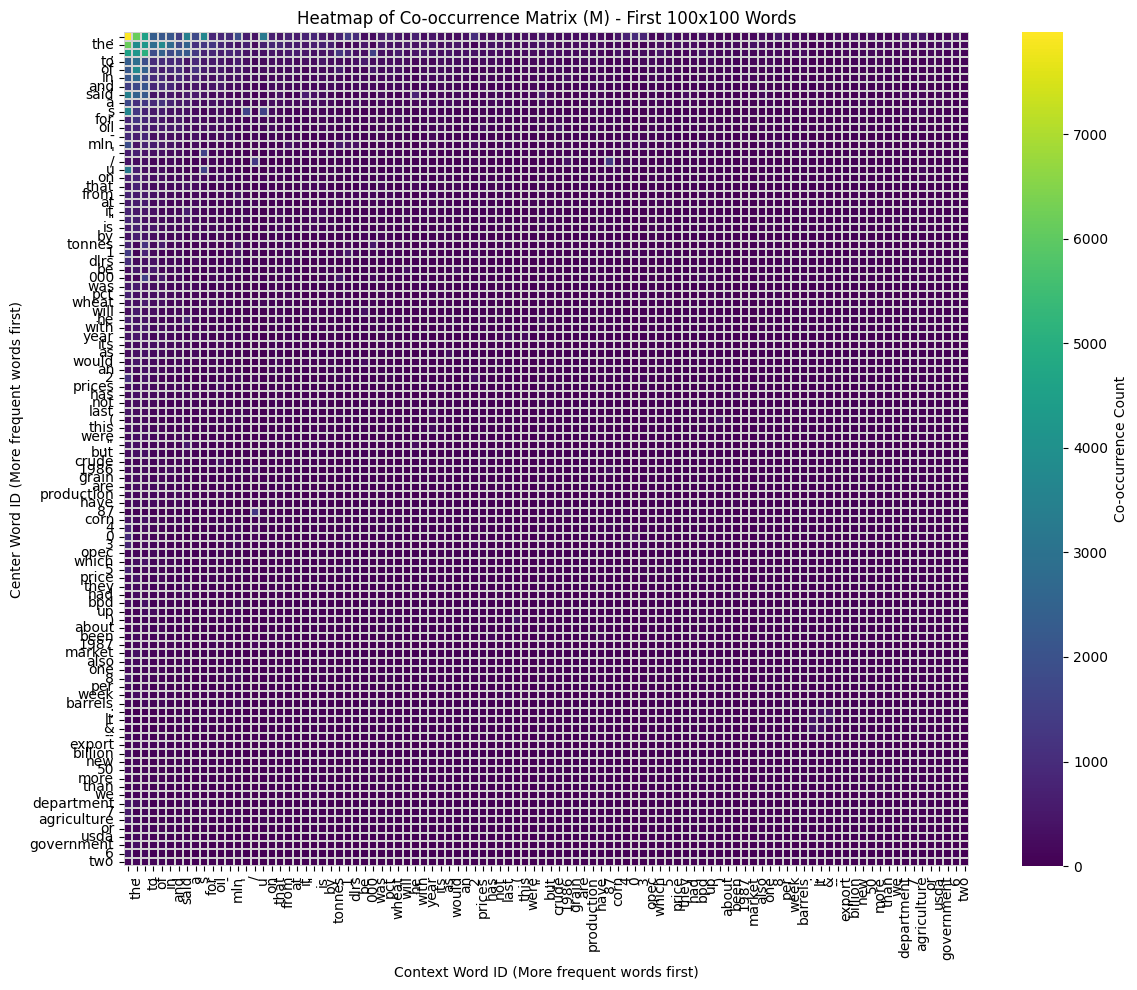

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Choose a subset size, e.g., the first 100 words
subset_size = 100
M_dense_subset = M[:subset_size, :subset_size]

plt.figure(figsize=(12, 10))
sns.heatmap(
    M_dense_subset,
    cmap="viridis", # A good colormap to show density
    cbar_kws={'label': 'Co-occurrence Count'},
    xticklabels=words[:subset_size], # Label with actual words for context
    yticklabels=words[:subset_size],
    linewidths=0.1, # Add subtle lines for distinction
    linecolor='lightgrey'
)
plt.title(f"Heatmap of Co-occurrence Matrix (M) - First {subset_size}x{subset_size} Words")
plt.xlabel("Context Word ID (More frequent words first)")
plt.ylabel("Center Word ID (More frequent words first)")
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

**El problema, ya visible en la forma.** La matriz es `(Vc, Vc)` — crece con el *cuadrado* del vocabulario. Con `V = 50.000` sería de 2.500 millones de entradas, casi todas cero: enorme y *sparse*. Y cada fila vive en `Vc` dimensiones: no la podemos ni mirar ni graficar.

La solución clásica es **comprimir** con **SVD** (*Singular Value Decomposition*): quedarnos con las direcciones más importantes, reduciendo cada fila de `Vc` dimensiones a unas pocas. Bajamos a 2 para poder graficar.

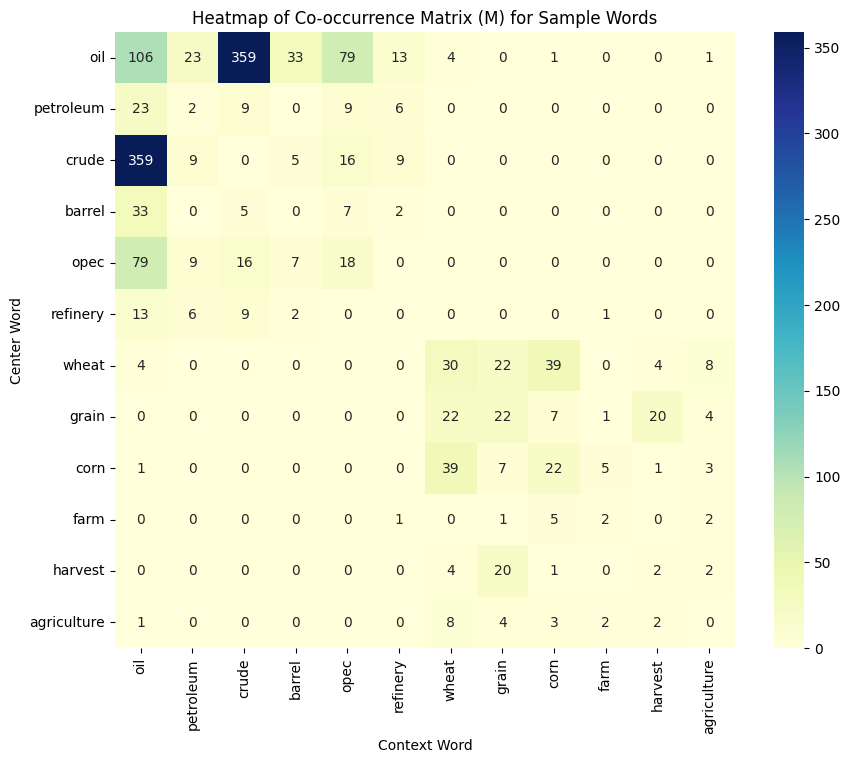

In [9]:
import seaborn as sns

# Graficamos un puñado de palabras de los dos temas para ver si se agrupan.
sample = ["oil", "petroleum", "crude", "barrel", "opec", "refinery",
          "wheat", "grain", "corn", "farm", "harvest", "agriculture"]
sample = [w for w in sample if w in w2i]       # nos quedamos sólo con las que están en el vocab


# Get indices for the sample words
sample_indices = [w2i[w] for w in sample if w in w2i]
sample_words = [w for w in sample if w in w2i]

# Create a sub-matrix from M for these words
M_sample = M[np.ix_(sample_indices, sample_indices)]

plt.figure(figsize=(10, 8))
sns.heatmap(
    M_sample,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    xticklabels=sample_words,
    yticklabels=sample_words
)
plt.title("Heatmap of Co-occurrence Matrix (M) for Sample Words")
plt.xlabel("Context Word")
plt.ylabel("Center Word")
plt.show()

antes: (1500, 1500)  ->  después: (1500, 2)


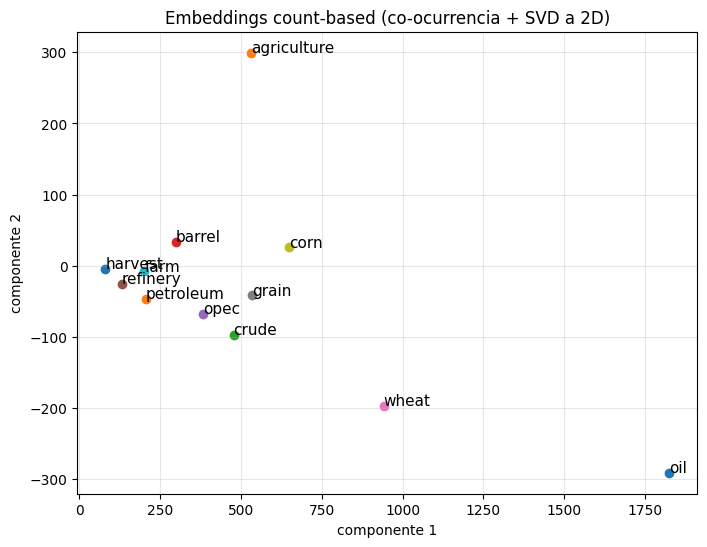

In [10]:
# SVD truncado: TruncatedSVD(n_components=2) reduce cada fila de Vc dimensiones a 2.
# fit_transform devuelve la matriz ya reducida: cada palabra pasa a ser un punto (x, y).
svd = TruncatedSVD(n_components=2, random_state=SEED)
M2 = svd.fit_transform(M)        # (Vc, Vc) -> (Vc, 2)
print("antes:", M.shape, " ->  después:", M2.shape)

plt.figure(figsize=(8, 6))
for w in sample:
    x, y = M2[w2i[w]]                           # las coordenadas 2D de la palabra w
    plt.scatter(x, y)
    plt.annotate(w, (x, y), fontsize=11)
plt.title("Embeddings count-based (co-ocurrencia + SVD a 2D)")
plt.xlabel("componente 1"); plt.ylabel("componente 2")
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
# ---- PPMI: sacamos el efecto de la frecuencia ----
# Con conteos crudos, la 1ra dirección de la SVD captura sólo "qué tan frecuente es la palabra",
#   no su significado (por eso 'oil' quedaba lejísimos de 'petroleum' aunque signifiquen casi lo mismo).
# PPMI lo corrige: usa cuánto MÁS co-ocurren dos palabras de lo esperable por azar.
#   PMI(i,j) = log( P(i,j) / (P(i)·P(j)) )  ;  PPMI = max(0, PMI).
Mf = M.astype(np.float64)
total = Mf.sum()
row = Mf.sum(axis=1, keepdims=True)          # frecuencia de cada palabra como central
col = Mf.sum(axis=0, keepdims=True)          # frecuencia como contexto
with np.errstate(divide="ignore", invalid="ignore"):
    pmi = np.log((Mf * total) / (row * col)) # el cociente P(i,j)/(P(i)·P(j)) simplificado
pmi[~np.isfinite(pmi)] = 0.0                 # donde no co-ocurren, log(0) = -inf -> 0
M_ppmi = np.maximum(pmi, 0.0)                # PPMI = parte positiva
# justo antes de la SVD:
M_ppmi = M_ppmi / (np.linalg.norm(M_ppmi, axis=1, keepdims=True) + 1e-9)
print("\nmatriz PPMI:", M_ppmi.shape)
print("muestra de M_ppmi (primeras 5x5 celdas):\n", M_ppmi[:5, :5].round(2))


matriz PPMI: (1500, 1500)
muestra de M_ppmi (primeras 5x5 celdas):
 [[0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.04]
 [0.   0.   0.02 0.   0.01]
 [0.   0.   0.   0.   0.  ]
 [0.   0.03 0.01 0.   0.  ]]


antes: (1500, 1500)  ->  después: (1500, 2)


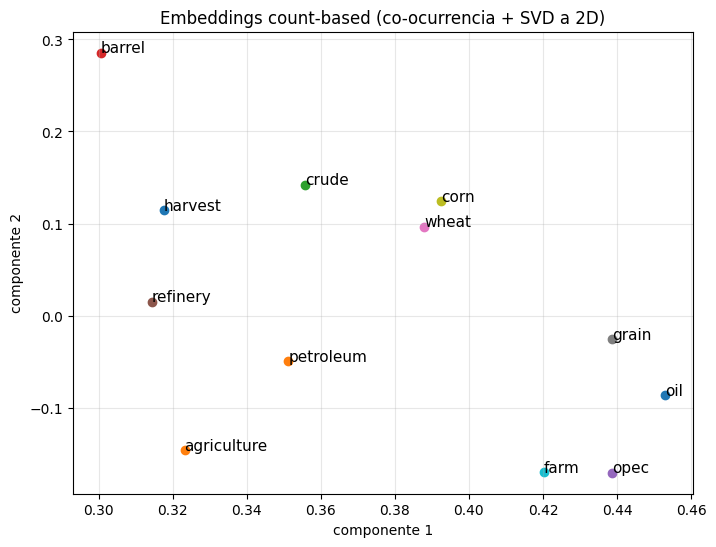

In [12]:
svd = TruncatedSVD(n_components=2, random_state=SEED)
M2 = svd.fit_transform(M_ppmi)        # (Vc, Vc) -> (Vc, 2)
print("antes:", M.shape, " ->  después:", M2.shape)

plt.figure(figsize=(8, 6))
for w in sample:
    x, y = M2[w2i[w]]                           # las coordenadas 2D de la palabra w
    plt.scatter(x, y)
    plt.annotate(w, (x, y), fontsize=11)
plt.title("Embeddings count-based (co-ocurrencia + SVD a 2D)")
plt.xlabel("componente 1"); plt.ylabel("componente 2")
plt.grid(True, alpha=0.3)
plt.show()

**Lo que se ve — y lo que no.** Aun contando de la forma más cruda, emerge geometría. Sin decirle a nadie qué significan, el puro conteo de contextos las agrupa por tema. Eso es la hipótesis distribucional funcionando.

Pero el método tiene techos claros:
- **Escala:** la matriz `(V, V)` es gigante y sparse; SVD sobre millones de palabras no escala bien.
- **Calidad:** las direcciones que salen son ruidosas y las analogías (las famosas `rey − hombre + mujer`) salen flojas.

> **Para discutir.** Contamos *primero* toda la matriz y *después* la comprimimos. ¿Y si en vez de contar-y-comprimir *aprendiéramos* los vectores directamente, optimizándolos para una tarea? Ese es el salto a **word2vec**.

## 4 — Predecir: entrenar word2vec

**El truco central de word2vec** (Mikolov et al., 2013): no modelamos el significado de frente. Inventamos una **tarea de predicción descartable**, y los vectores que el modelo necesita para resolverla *son* nuestros embeddings. La tarea es la excusa; los pesos son el premio.

**Skip-gram**, la variante que se suele enseñar: dada una palabra *central*, predecir sus *vecinas* dentro de una ventana. Deslizando la ventana por todo el corpus se generan millones de pares (central, contexto) — sin etiquetar nada a mano (*self-supervised*).

El mecanismo: cada palabra tiene un vector; el modelo puntúa un par con el **producto punto** de los vectores, y entrena para que ese producto sea alto entre palabras que de verdad co-ocurren. Para lograrlo, se ve forzado a darles vectores parecidos a las palabras que viven en contextos parecidos — y el significado cae de la geometría.

> **Nota.** El softmax original suma sobre las `V` palabras del vocabulario en *cada* par: carísimo. El truco que lo hizo rápido es **negative sampling**: en vez de "elegí la correcta entre `V`", se reformula como "distinguí pares reales de unos pocos pares falsos (central + palabra random)". Lo vemos por dentro en la Sección 7.

Acá lo entrenamos con gensim sobre **text8** (~17M palabras de Wikipedia).

In [13]:
# api.load("text8"): baja text8 (~30 MB, ~17M palabras de Wikipedia) como un iterable de listas de palabras.
dataset = api.load("text8")

# Word2Vec entrena los embeddings. Los parámetros clave, comentados:
w2v = Word2Vec(
    dataset,
    vector_size=100,   # dimensión de cada embedding
    window=5,          # tamaño de la ventana de contexto
    min_count=5,       # ignora palabras con menos de 5 apariciones
    sg=1,              # 1 = skip-gram (0 sería CBOW)
    negative=5,        # negative sampling: 5 negativos por positivo
    epochs=3,          # pasadas por el corpus (esto tarda unos minutos en CPU)
    workers=4,
)

# w2v.wv es el KeyedVectors: la tabla de vectores ya entrenada, indexada por palabra.
print("palabras en el vocabulario:", len(w2v.wv))
print("shape del embedding de 'king':", w2v.wv["king"].shape)   # (100,)
print("ejemplo de palabras del vocabulario:", w2v.wv.index_to_key[:20])

[==================================================] 100.0% 31.6/31.6MB downloaded
palabras en el vocabulario: 71290
shape del embedding de 'king': (100,)
ejemplo de palabras del vocabulario: ['the', 'of', 'and', 'one', 'in', 'a', 'to', 'zero', 'nine', 'two', 'is', 'as', 'eight', 'for', 's', 'five', 'three', 'was', 'by', 'that']


**¿Aprendió algo real?** El corpus es chico, así que no esperemos milagros — pero veamos si los vecinos y una analogía tienen sentido.

In [14]:
# most_similar(w): las palabras cuyos vectores tienen mayor coseno con el de w.
print("Vecinos de 'king' (los más cercanos por coseno):")
for w, s in w2v.wv.most_similar("king", topn=5):
    print(f"  {w:12s} {s:.3f}")

# Analogía: positive suma vectores, negative resta -> king - man + woman.
print("\nAnalogía  king - man + woman ≈ ?")
for w, s in w2v.wv.most_similar(positive=["king", "woman"], negative=["man"], topn=3):
    print(f"  {w:12s} {s:.3f}")

print("\nAnalogía  doctor - man + woman ≈ ?")
for w, s in w2v.wv.most_similar(positive=["doctor", "woman"], negative=["man"], topn=3):
    print(f"  {w:12s} {s:.3f}")


Vecinos de 'king' (los más cercanos por coseno):
  prince       0.801
  pretender    0.739
  haakon       0.737
  aragon       0.731
  throne       0.729

Analogía  king - man + woman ≈ ?
  throne       0.668
  prince       0.649
  queen        0.640

Analogía  doctor - man + woman ≈ ?
  nurse        0.666
  child        0.662
  helen        0.585


**Lo que se ve.** Aun con un corpus modesto, `most_similar` devuelve palabras del mismo campo semántico, y la analogía apunta en la dirección correcta. Es real: el modelo aprendió geometría con significado, sólo prediciendo contextos.

**El límite honesto.** Con text8 los resultados son decentes pero ruidosos; las analogías famosas y limpias necesitan **mucho** más texto. En vez de entrenar horas, en la próxima sección *cargamos* vectores pre-entrenados a gran escala.

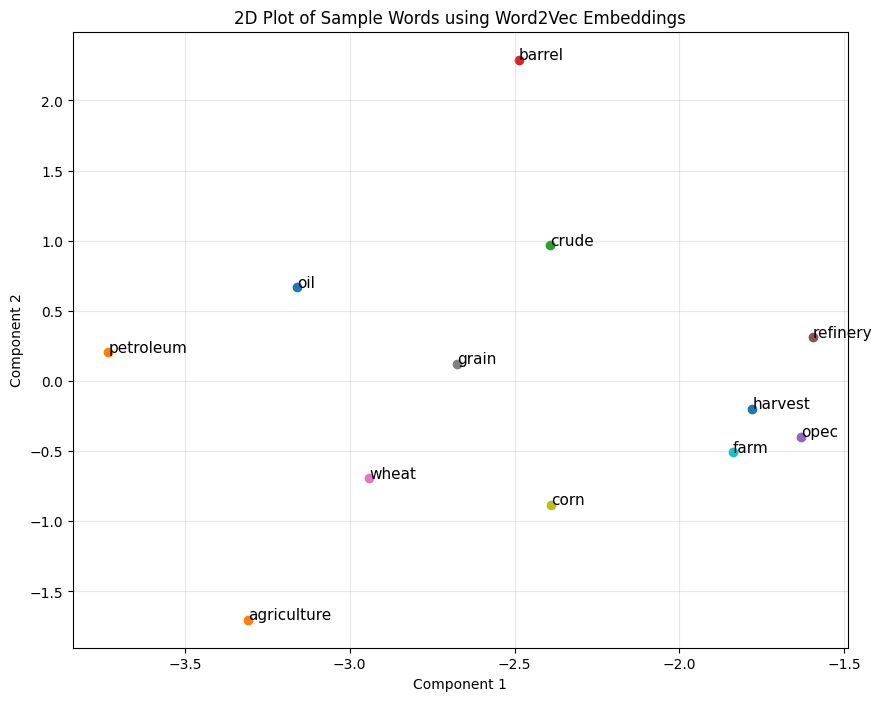

In [15]:
words_in_w2v = [w for w in sample if w in w2v.wv]

# Extract word vectors for the sample words
word_vectors = np.array([w2v.wv[w] for w in words_in_w2v])

# Reduce dimensionality to 2D using TruncatedSVD
svd_w2v = TruncatedSVD(n_components=2, random_state=SEED)
word_vectors_2d = svd_w2v.fit_transform(word_vectors)

# Plot the 2D embeddings
plt.figure(figsize=(10, 8))
for i, word in enumerate(words_in_w2v):
    x, y = word_vectors_2d[i]
    plt.scatter(x, y)
    plt.annotate(word, (x, y), fontsize=11)

plt.title("2D Plot of Sample Words using Word2Vec Embeddings")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True, alpha=0.3)
plt.show()

## 5 — Explorar a escala: GloVe pre-entrenado

**GloVe** (Pennington, Socher & Manning, 2014 — Stanford) es el tercer paso: **contar y después aprender**. Los métodos de conteo (Sección 3) usan estadística *global* pero salían flojos; word2vec (Sección 4) aprende bien pero *streamea* ventanas locales y nunca mira los conteos globales de frente. GloVe se queda con lo mejor de los dos: parte de la matriz de co-ocurrencia global y **ajusta** los vectores para que `wᵢ · wⱼ ≈ log(conteo(i, j))`, con pesos que silencian los pares raros y capean los muy frecuentes.

> **La intuición del paper.** Lo que carga significado no es la probabilidad de co-ocurrencia cruda sino el **cociente**. Para separar "ice" de "steam", miramos `P(k | ice) / P(k | steam)`: para "solid" el cociente es alto (va con ice), para "gas" es bajo (va con steam), y para "water" o "fashion" es ≈ 1 (irrelevante). El cociente discrimina; la probabilidad sola, no.

Acá **cargamos** GloVe pre-entrenado (400.000 palabras, entrenado sobre 6.000M de tokens) en vez de entrenarlo — que es, en concreto, el punto de escala de la sección anterior.

In [16]:
# api.load(...): baja los vectores GloVe pre-entrenados (~130 MB la primera vez).
# Devuelve un KeyedVectors: la misma interfaz que w2v.wv, pero ya entrenado a gran escala.
glove = api.load("glove-wiki-gigaword-100")

print("palabras en el vocabulario:", len(glove))
print("dimensión de cada vector:", glove["king"].shape)   # (100,)
print("ejemplo de palabras:", glove.index_to_key[:20])

[==================================================] 100.0% 128.1/128.1MB downloaded
palabras en el vocabulario: 400000
dimensión de cada vector: (100,)
ejemplo de palabras: ['the', ',', '.', 'of', 'to', 'and', 'in', 'a', '"', "'s", 'for', '-', 'that', 'on', 'is', 'was', 'said', 'with', 'he', 'as']


### El coseno sobre vectores reales: por qué coseno y no euclidiana

Ya tenemos la regla (Sección 1). Dos notas de diseño ahora que la aplicamos a embeddings de verdad:

**Por qué coseno y no distancia euclidiana.** Nos importa la *dirección* (el significado), no la *magnitud*. Y la magnitud de un vector de palabra correlaciona con su frecuencia — algo que en general queremos factorizar afuera. El coseno normaliza esa magnitud y compara pura orientación; la euclidiana mezclaría el largo (y con él la frecuencia) con el parecido semántico.

**Sanity check.** Confirmemos que nuestra `cosine` de la Sección 1 da lo mismo que el `similarity` que trae gensim.

In [17]:
# Reusamos la `cosine` de la Sección 1 y la comparamos con el .similarity de gensim: deben coincidir.
for a, b in [("king", "queen"), ("king", "throne"), ("king", "avocado")]:
    manual  = cosine(glove[a], glove[b])       # nuestra fórmula
    builtin = glove.similarity(a, b)           # la de gensim
    print(f"cos({a}, {b}) = {manual:.3f}   (gensim: {builtin:.3f})")

cos(king, queen) = 0.751   (gensim: 0.751)
cos(king, throne) = 0.692   (gensim: 0.692)
cos(king, avocado) = 0.042   (gensim: 0.042)


**Sanity check.** Nuestro coseno y el de gensim coinciden. Y el número refleja el significado: `king`–`queen` alto, `king`–`throne` medio, `king`–`avocado` bajo. La geometría *es* consultable.

In [18]:
# most_similar -> "los más cercanos por coseno", la operación base de la búsqueda semántica.
for query in ["king", "computer", "music"]:
    print(f"Vecinos de '{query}':")
    for w, s in glove.most_similar(query, topn=5):
        print(f"  {w:14s} {s:.3f}")
    print()

Vecinos de 'king':
  prince         0.768
  queen          0.751
  son            0.702
  brother        0.699
  monarch        0.698

Vecinos de 'computer':
  computers      0.875
  software       0.837
  technology     0.764
  pc             0.737
  hardware       0.729

Vecinos de 'music':
  musical        0.813
  songs          0.798
  dance          0.790
  pop            0.786
  recording      0.765



### El resultado famoso: analogías como aritmética de vectores

Lo que hizo famoso a este espacio es que las **direcciones** codifican relaciones. `rey − hombre + mujer ≈ reina`: si a "king" le restás la dirección de "hombre" y le sumás la de "mujer", caés cerca de "queen". Lo mismo con capital-de-país o singular-plural. No era obvio que fuera a pasar.

In [19]:
# analogy(a, b, c): resuelve "a es a b como c es a ?" = most_similar(positive=[b, c], negative=[a]).
def analogy(a, b, c, kv=glove):
    res = kv.most_similar(positive=[b, c], negative=[a], topn=1)[0]   # [0] = el primer resultado (palabra, score)
    print(f"  {a} : {b}  ::  {c} : {res[0]}   ({res[1]:.3f})")

print("Analogías con GloVe:")
analogy("man", "king", "woman")            # king   - man     + woman    -> queen
analogy("france", "paris", "italy")        # paris  - france  + italy    -> rome
analogy("good", "better", "bad")           # better - good    + bad      -> worse
analogy("walking", "walked", "swimming")   # walked - walking + swimming -> swam

Analogías con GloVe:
  man : king  ::  woman : queen   (0.770)
  france : paris  ::  italy : rome   (0.819)
  good : better  ::  bad : worse   (0.844)
  walking : walked  ::  swimming : athletics   (0.621)


### Un techo de este enfoque: polisemia

Estos son **static embeddings**: un vector *fijo por palabra*, ciego al contexto. ¿Qué pasa con una palabra que tiene varios sentidos?

In [20]:
# 'bank' tiene dos sentidos (río / finanzas) pero un solo vector: veamos qué vecinos trae.
print("Vecinos de 'bank':")
for w, s in glove.most_similar("bank", topn=8):
    print(f"  {w:14s} {s:.3f}")

Vecinos de 'bank':
  banks          0.806
  banking        0.753
  credit         0.704
  investment     0.694
  financial      0.678
  securities     0.669
  lending        0.665
  funds          0.648


**Lo que se ve.** El vector de `bank` está dominado por un sentido (el financiero, el más frecuente en el corpus) y el otro (la orilla del río) casi no aparece. Un único vector no puede sostener los dos sentidos a la vez: los promedia o deja ganar al más común. **Ese es el techo de los static embeddings.**

¿Cómo se rompe? Con **embeddings contextuales** — un vector distinto por token según sus vecinos. Que es, exactamente, lo que hace self-attention: lo que ustedes construyeron en la Clase 2. Volvemos a esto en el cierre.

### Los embeddings aprenden lo que hay en los datos (verrugas incluidas)

Si el espacio captura las regularidades del corpus, también captura sus **sesgos**. Las analogías lo dejan ver de forma incómoda.

In [21]:
# La misma maquinaria de analogías, ahora sobre una relación cargada -> deja ver el sesgo del corpus.
print("man : doctor  ::  woman : ?")
for w, s in glove.most_similar(positive=["woman", "doctor"], negative=["man"], topn=5):
    print(f"  {w:14s} {s:.3f}")

man : doctor  ::  woman : ?
  nurse          0.774
  physician      0.719
  doctors        0.682
  patient        0.675
  dentist        0.673


> **Para discutir.** El corpus refleja el mundo (y sus desigualdades), y el embedding los hereda: en analogías de profesión aparecen asociaciones de género que nadie programó. Esto no es una curiosidad: son los vectores que después alimentan buscadores, sistemas de RAG y modelos productivos. Medir y mitigar estos sesgos es parte de *responsible AI* (Unidad 2).

## 6 — Cierre: la bisagra hacia lo contextual

Recorrimos el arco completo de cómo llenar la tabla de embeddings con significado:

| Enfoque | Idea | Qué da |
|---|---|---|
| **one-hot** | identidad | vectores ortogonales — cero significado |
| **contar** (co-ocurrencia + SVD) | hipótesis distribucional | geometría, pero ruidosa y no escala |
| **predecir** (word2vec) | aprender resolviendo una tarea | analogías, self-supervised |
| **GloVe** | contar *y* aprender | lo mejor de los dos |

Los cuatro comparten un techo: dan **static embeddings** — un vector fijo por palabra, ciego al contexto (el problema de `bank`). El siguiente escalón, los **embeddings contextuales**, lo rompe: un vector distinto por token según sus vecinos. Eso es self-attention, y ya lo construyeron en la Clase 2. El arco entero es:

> **one-hot** (identidad) → **static embeddings** (significado, ciego al contexto) → **contextual embeddings** (significado que depende del contexto).

**El paréntesis, cerrado.** word2vec y GloVe son un desvío para entender embeddings como espacio geométrico. Pero no son sólo historia: el paradigma "un modelo de embeddings entrenado por su cuenta" está vivo y es el motor de **RAG**. La operación `most_similar` que usamos toda la sección —buscar los vectores más cercanos por coseno— *es* la recuperación en RAG.

En el **Notebook 2** damos el paso de la palabra a la oración (*sentence embeddings*) y montamos búsqueda semántica sobre eso. *Búsqueda semántica y RAG: Notebook 2 y Semana 8.*

## 7 — Skip-gram + negative sampling desde cero

En la Sección 4 gensim entrenó word2vec por nosotros. Acá abrimos la caja: implementamos **skip-gram con negative sampling** a mano en PyTorch, para ver el mecanismo que mencionamos.

**La reformulación clave.** En vez de "predecir la palabra correcta entre `V`" (softmax carísimo), lo convertimos en **`k + 1` problemitas binarios** por cada par central–contexto:
- el par real (central, contexto) → etiqueta **1** ("¿co-ocurren? sí")
- `k` pares falsos (central, palabra random) → etiqueta **0** ("¿co-ocurren? no")

Cada palabra tiene dos vectores (uno como central, otro como contexto); el score de un par es su producto punto, pasado por una sigmoide. Entrenamos para subir el score de los reales y bajar el de los falsos. Eso es `O(k)` por par en vez de `O(V)`.

> **Ojo.** Con un corpus chico y pocos epochs los vectores salen flojos — el punto es el *mecanismo*, no la calidad (para calidad ya está gensim, Sección 4).

In [22]:
# ---- Corpus chico: los primeros ~50k tokens de text8 (ya descargado en la Sección 4) ----
tokens = []
for chunk in api.load("text8"):        # text8 viene en chunks de palabras
    tokens.extend(chunk)
    if len(tokens) >= 50000:
        break
tokens = tokens[:50000]

# Vocabulario (palabras con >= 5 apariciones) y corpus codificado a IDs.
counts = Counter(tokens)                                     # frecuencia de cada palabra
itos6 = [w for w, c in counts.items() if c >= 5]             # index-to-string: lista de palabras del vocab
stoi6 = {w: i for i, w in enumerate(itos6)}                  # string-to-index: palabra -> id
Vn = len(itos6)
data_ids = [stoi6[w] for w in tokens if w in stoi6]         # el corpus como lista de IDs (sin las palabras raras)
print("tokens:", len(tokens), "| vocabulario:", Vn, "| corpus codificado:", len(data_ids))

# ---- Pares (central, contexto) con ventana ----
# Para cada palabra central, un par con cada vecina dentro de la ventana.
WINDOW = 2
centers, contexts = [], []
for i, c in enumerate(data_ids):
    for j in range(max(0, i - WINDOW), min(len(data_ids), i + WINDOW + 1)):
        if j != i:                                   # sin emparejar la palabra consigo misma
            centers.append(c); contexts.append(data_ids[j])
centers  = torch.tensor(centers)     # (P,)
contexts = torch.tensor(contexts)    # (P,)
P = len(centers)
print("pares de entrenamiento:", P)
print("ejemplo de pares (central -> contexto):")
for k in range(5):
    print(f"  {itos6[centers[k].item()]:12s} -> {itos6[contexts[k].item()]}")

# ---- Distribución para muestrear negativos: frecuencia^0.75 (como el paper) ----
# Elevar a 0.75 aplana la distribución: las palabras muy frecuentes se muestrean un poco menos.
freqs = np.array([counts[itos6[i]] for i in range(Vn)], dtype=np.float64) ** 0.75
neg_probs = torch.tensor(freqs / freqs.sum())        # normalizado para que sume 1

# ---- Modelo: dos tablas de embeddings (central y contexto) ----
EMB = 50
K = 5   # negativos por positivo
torch.manual_seed(SEED)
W_in  = nn.Embedding(Vn, EMB)    # vectores como palabra central
W_out = nn.Embedding(Vn, EMB)    # vectores como contexto
opt = torch.optim.Adam(list(W_in.parameters()) + list(W_out.parameters()), lr=5e-3)

# ---- Entrenamiento por minibatches ----
BATCH, EPOCHS = 4096, 5
for epoch in range(EPOCHS):
    perm = torch.randperm(P)                          # barajamos el orden de los pares
    total = 0.0
    for start in range(0, P, BATCH):
        b   = perm[start:start + BATCH]
        cen = centers[b]                                                  # (B,)
        pos = contexts[b]                                                 # (B,)
        # K negativos random por cada par, muestreados de la distribución de frecuencias.
        neg = torch.multinomial(neg_probs, len(b) * K, replacement=True).view(len(b), K)  # (B, K)

        v_cen = W_in(cen)                                                 # (B, EMB)
        v_pos = W_out(pos)                                                # (B, EMB)
        v_neg = W_out(neg)                                                # (B, K, EMB)

        # producto punto central·contexto -> logsigmoid: queremos el score ALTO para el par real.
        pos_score = F.logsigmoid((v_cen * v_pos).sum(dim=1))              # (B,)
        # para los negativos, logsigmoid del NEGATIVO del score: queremos el score BAJO.
        neg_score = F.logsigmoid(-(v_neg * v_cen.unsqueeze(1)).sum(dim=2)).sum(dim=1)  # (B,)
        loss = -(pos_score + neg_score).mean()                           # maximizar -> minimizamos el negativo

        opt.zero_grad(); loss.backward(); opt.step()
        total += loss.item() * len(b)
    print(f"epoch {epoch+1}/{EPOCHS}  loss {total / P:.4f}")

tokens: 50000 | vocabulario: 1467 | corpus codificado: 39973
pares de entrenamiento: 159886
ejemplo de pares (central -> contexto):
  anarchism    -> as
  anarchism    -> a
  as           -> anarchism
  as           -> a
  as           -> term
epoch 1/5  loss 15.6239
epoch 2/5  loss 12.5684
epoch 3/5  loss 10.3123
epoch 4/5  loss 8.5331
epoch 5/5  loss 7.1203


**Lo que se ve.** La loss baja epoch a epoch: el modelo aprende a separar pares reales de falsos. Los vectores de `W_in` son nuestros embeddings.

In [23]:
# Usamos W_in como embeddings finales. Normalizamos cada vector (dividir por su norma)
# para que el producto punto entre dos vectores sea directamente su coseno.
emb = W_in.weight.detach().numpy()                       # (Vn, EMB)
emb_norm = emb / np.linalg.norm(emb, axis=1, keepdims=True)

# nearest(word): coseno de word contra todo el vocab, ordena de mayor a menor y muestra el top.
def nearest(word, topn=5):
    if word not in stoi6:
        print(f"'{word}' no está en el vocabulario chico"); return
    q = emb_norm[stoi6[word]]                            # el vector (normalizado) de word
    sims = emb_norm @ q                                  # coseno contra todo el vocab, de una
    order = np.argsort(-sims)                            # índices ordenados por coseno descendente
    print(f"Vecinos de '{word}':")
    for i in order[1:topn + 1]:                          # saltamos la palabra misma (el primero es ella)
        print(f"  {itos6[i]:14s} {sims[i]:.3f}")

for w in ["one", "two", "government"]:
    nearest(w); print()

Vecinos de 'one':
  albedo         0.595
  modes          0.510
  wife           0.507
  behind         0.503
  phenomena      0.497

Vecinos de 'two':
  skills         0.467
  letters        0.463
  receiving      0.449
  throughout     0.417
  free           0.414

Vecinos de 'government':
  behind         0.452
  nine           0.451
  class          0.444
  tend           0.408
  duty           0.397



**Lo que se ve.** Con 50k tokens y 5 epochs los vecinos son ruidosos —a veces aciertan (números que se agrupan), a veces no—. Es esperable: **la geometría linda necesita escala**, y por eso en producción se usa gensim o vectores pre-entrenados. Pero el *mecanismo* quedó a la vista: pares reales vs falsos, producto punto, sigmoide, gradiente.

**Por qué esto fue una sección y no el camino principal.** En la Clase 1 construyeron un motor de autograd (micrograd) y en la Clase 2 un Transformer (nanoGPT): ya saben armar un training loop. Lo *nuevo* de esta clase no es el loop — es la **geometría** (coseno, analogías, búsqueda semántica). Por eso el camino principal fue explorar el espacio, y las tripas quedaron acá, para quien quiera verlas.